In [2]:
#Use TensorFlow to execute the deep-learning models

In [3]:
from tensorflow.keras.datasets import mnist

In [4]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()            #Loads the MNIST training and testing sets

In [5]:
X_train.shape       #Training set images

(60000, 28, 28)

In [6]:
y_train.shape       #Training set labels

(60000,)

In [7]:
X_test.shape        #Testing set images

(10000, 28, 28)

In [8]:
y_test.shape       #Testing set labels

(10000,)

In [9]:
#Visualizing Digits

In [10]:
#%matplotlib inline              #Graphics should be displayed in the notebook

In [11]:
import matplotlib.pyplot as plt

In [12]:
import seaborn as sns

In [13]:
sns.set(font_scale=2)

In [14]:
import numpy as np

In [15]:
index = np.random.choice(
    np.arange(len(X_train)),            #Array of values you want to select
    24,                                 #Number of elements to select
    replace=False
)

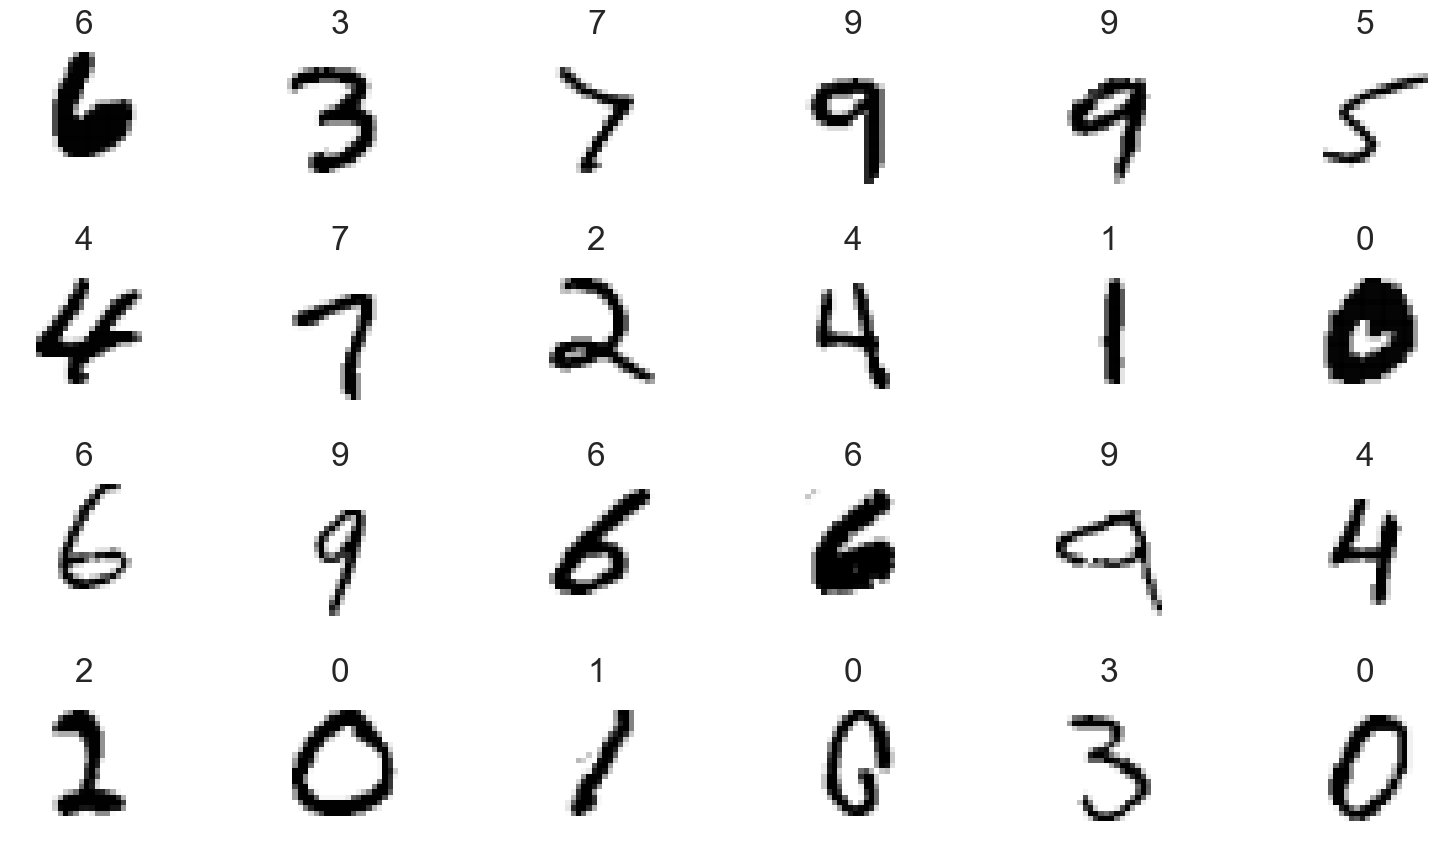

In [16]:
figure, axes = plt.subplots(nrows=4, ncols=6, figsize=(16,9))
for item in zip(axes.ravel(), X_train[index], y_train[index]):
    axes, image, target = item
    axes.imshow(image, cmap=plt.cm.gray_r)
    axes.set_xticks([])             #Remove marks
    axes.set_yticks([])
    axes.set_title(target)
plt.tight_layout()

In [17]:
#Reshape the data for  NumPy array with the shape (width, height, channels)

In [18]:
X_train = X_train.reshape((60000, 28, 28, 1))           #It receives a tuple representing the array's new shape

In [19]:
X_train.shape

(60000, 28, 28, 1)

In [20]:
X_test = X_test.reshape((10000, 28, 28, 1))

In [21]:
X_test.shape

(10000, 28, 28, 1)

In [22]:
#Normalized values in the range

In [23]:
X_train = X_train.astype('float32')/255
X_test = X_test.astype('float32')/255

In [24]:
from tensorflow.keras.utils import to_categorical

In [25]:
y_train = to_categorical(y_train)

In [26]:
y_train.shape

(60000, 10)

In [27]:
y_train[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

In [28]:
y_test = to_categorical(y_test)

In [29]:
y_test.shape

(10000, 10)

In [30]:
y_test[0]

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])

In [31]:
#Creating the Neural Network

In [32]:
from tensorflow.keras.models import Sequential

In [33]:
cnn = Sequential()

In [34]:
#Adding a Convultion Layers to the Network

In [35]:
from tensorflow.keras.layers import Conv2D, Dense, Flatten, MaxPooling2D

In [36]:
cnn.add(Conv2D(
    filters=64,             #Number of filters in the resulting feature map
    kernel_size=(3,3),      #Size of the kernel used in each feature
    activation='relu',      #Produce this layer's output (RELU Activation Function)
    input_shape=(28,28,1)   #Specify the shape of each sample. Creates an input layer to load the samples and pass them inot the layer
))
#output 26-by-26-by-64

C:\Users\H\Programación\Python\Deitel\Python\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
#Adding a pooling layer (help reduce the dimensionality 75%)

In [38]:
cnn.add(MaxPooling2D(pool_size=(2,2)))
#output 13-by-13-by-64

In [39]:
#Adding a convultion layer and pooling layer to lear more relationships between the features

In [40]:
#The input is the 13-by-13-by-64 output of the first pooling layer
cnn.add(Conv2D(
    filters=128,             #Number of filters in the resulting feature map
    kernel_size=(3,3),      #Size of the kernel used in each feature
    activation='relu',      #Produce this layer's output (RELU Activation Function)
))
#Output 11 x 11 x 128 (10 x 10 x 128)

In [41]:
cnn.add(MaxPooling2D(pool_size=(2,2)))
#Output 5 x 5 x 128

In [42]:
#prepare for the one-dimensional final predictions with Flatten

In [43]:
cnn.add(Flatten())
#output 1 x 3200; 5*5*128=3200

In [44]:
#Learning the relationships among features and performing classification  is with Dense layers

In [45]:
#Create 128 neurons (units) that learn from the 3200 outputs
cnn.add(Dense(units=128, activation='relu'))

In [46]:
#Adding another dense layer to produce the final output (neurons representing the classes 0 - 9)

In [47]:
cnn.add(Dense(units=10, activation='softmax'))
#softmax activation function converts the values of these remaining 10 neurons into classification probabilities
#The neuron that produces the highest probability (1.0) represents the prediction for a given digit image

In [48]:
#Printing the Model's Summary with summary method

In [49]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 485,514 (1.85 MB)

 Trainable params: 485,514 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

In [50]:
#Visualizing a Model's Structure with plot_model function

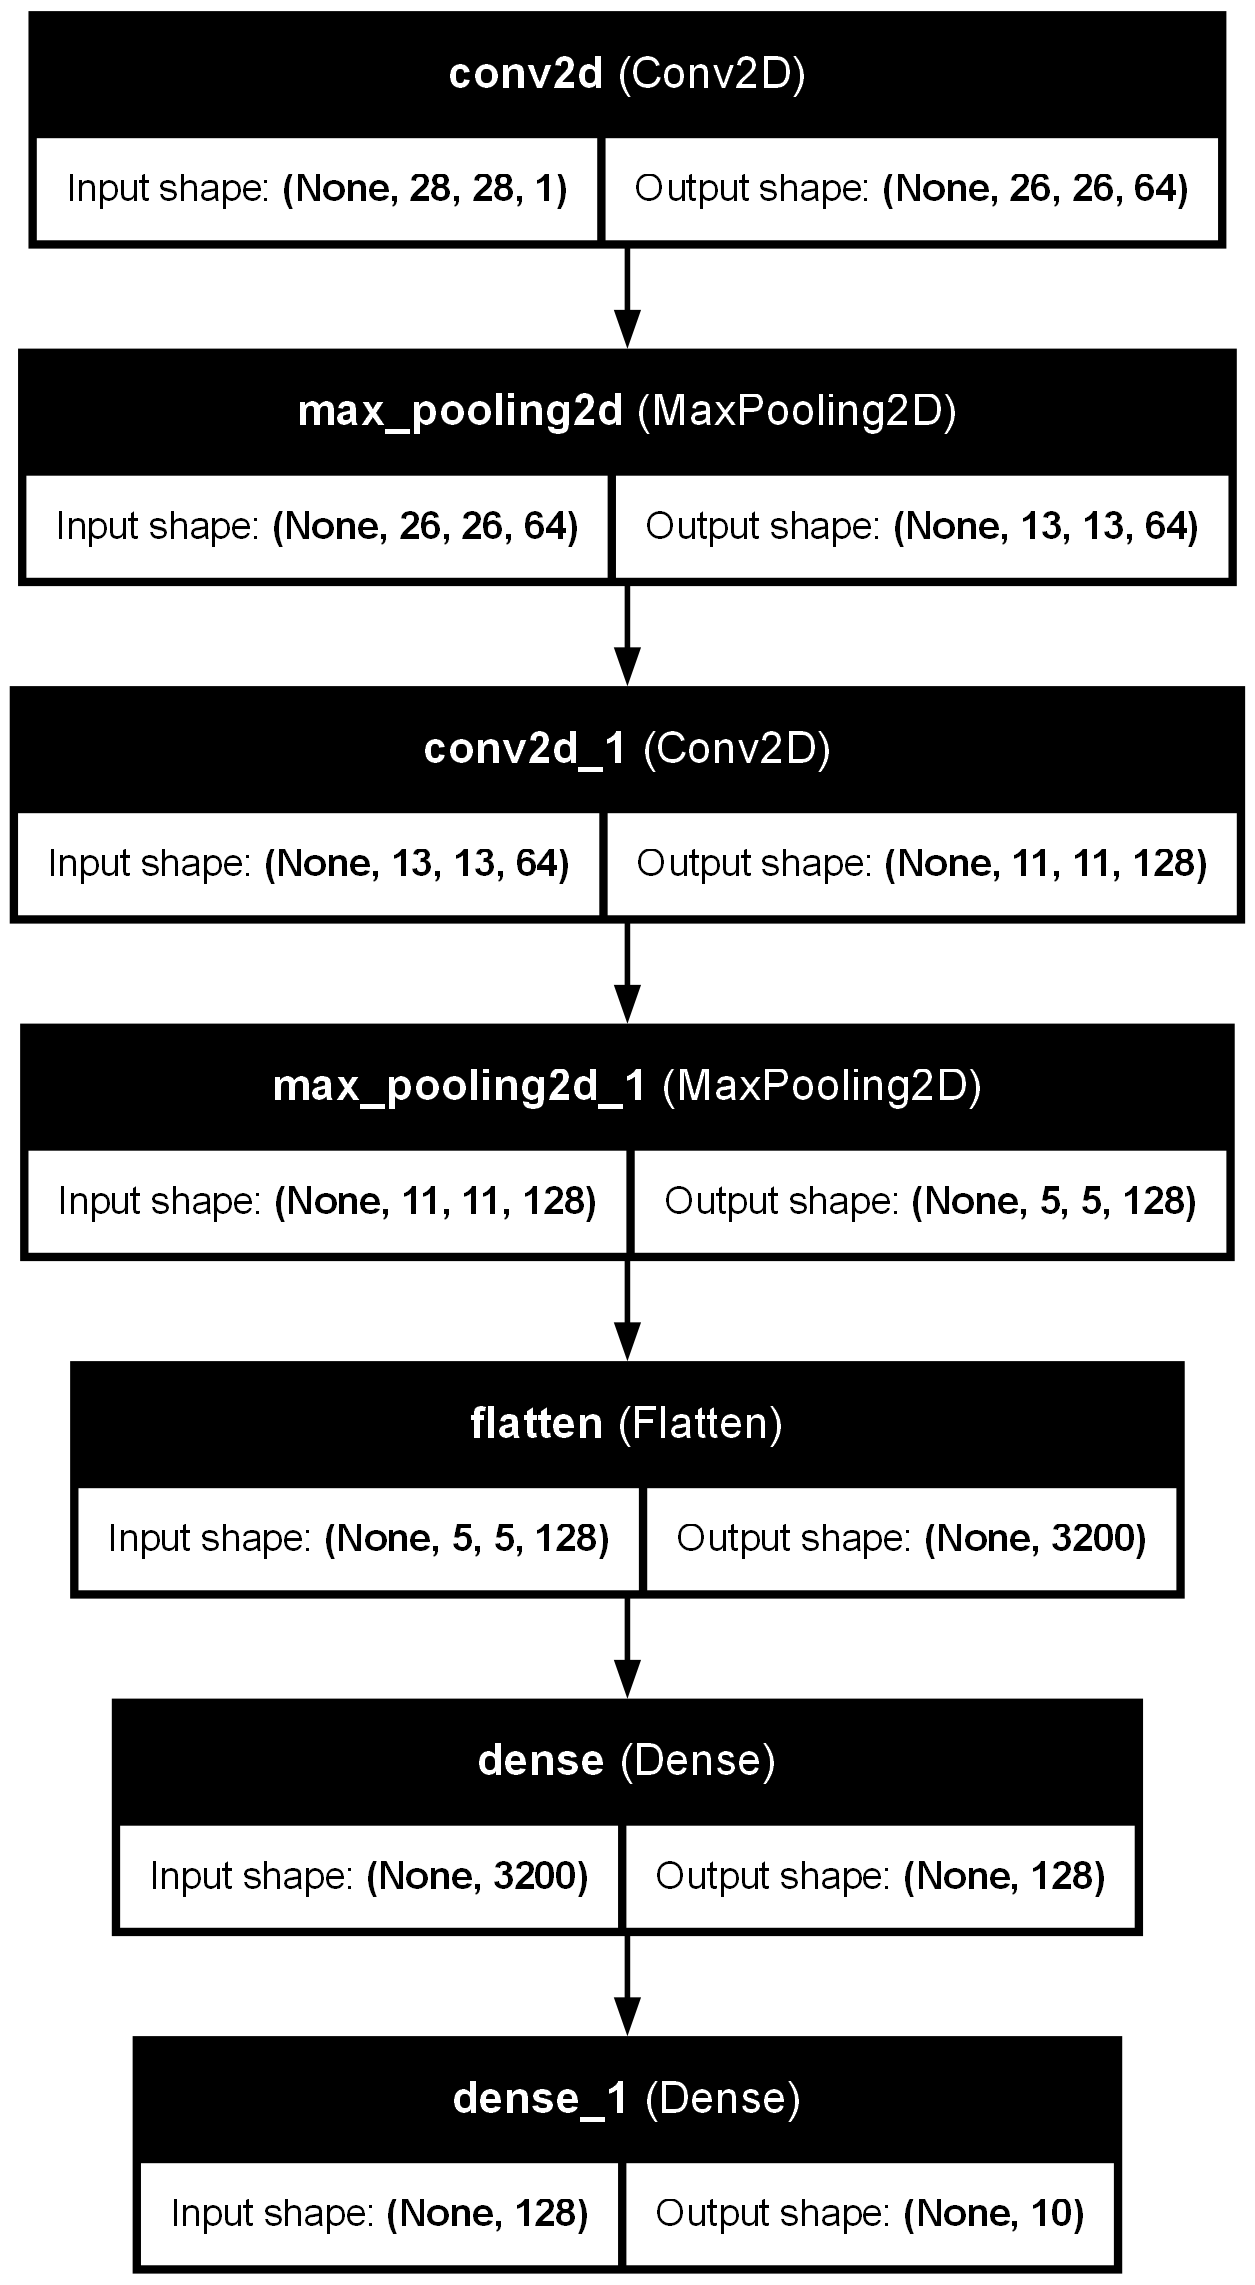

In [51]:
from tensorflow.keras.utils import plot_model
from IPython.display import Image
plot_model(                         #Store the visualization
    cnn,
    to_file='convnet.png',
    show_shapes=True,
    show_layer_names=True
)
Image(filename='convnet.png')           #Show the image in the notebook

In [52]:
#Compiling the model to complete the model

In [53]:
cnn.compile(
    optimizer='adam',           #Adjust the weights throughout the neural network as it learns
    loss='categorical_crossentropy',    #Used by the optimizer in multi-classification networks to lower the loss
    metrics=['accuracy'])           #List of metrics that the network will produce to help you evaluate the model

In [54]:
cnn.fit(X_train, y_train,
        epochs=5,               #Number of times the model should process the entire set of training data
        batch_size=64,          #Specifies the number of samples to process at a time during each epochs
        validation_split=0.1    #The model should reserve the last 10% of training samples for validation
        )

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9555 - loss: 0.1431 - val_accuracy: 0.9832 - val_loss: 0.0586
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9870 - loss: 0.0425 - val_accuracy: 0.9885 - val_loss: 0.0375
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9914 - loss: 0.0276 - val_accuracy: 0.9908 - val_loss: 0.0321
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9935 - loss: 0.0203 - val_accuracy: 0.9913 - val_loss: 0.0289
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9951 - loss: 0.0150 - val_accuracy: 0.9917 - val_loss: 0.0309


In [55]:
#Evaluating the model which displays as its output how long it took to process the test samples

In [56]:
loss, accuracy = cnn.evaluate(X_test, y_test)
#It shows the accurate when predicting the labels for unseen data

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9906 - loss: 0.0306


In [59]:
#Making predictions with predict method; predict the classes of the digit images in its argument array

In [60]:
predictions = cnn.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [61]:
y_test[0]

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])

In [62]:
#Checking the probabilities returned ny the predict method for the first test sample

In [63]:
for index, probability in enumerate(predictions[0]):
    print(f'{index}: {probability:.10%}')

0: 0.0000000486%
1: 0.0000000023%
2: 0.0000321749%
3: 0.0000088200%
4: 0.0000000004%
5: 0.0000000542%
6: 0.0000000000%
7: 99.9999403954%
8: 0.0000000308%
9: 0.0000121257%


In [64]:
#Locating the incorrect predictions

In [68]:
images =  X_test.reshape((10000, 28, 28))       #Reshape to display the images to (28, 28) originally it was (28,28,1)

In [66]:
incorrect_predictions=[]

In [67]:
for i, (p, e) in enumerate(zip(predictions, y_test)):
    predicted, expected = np.argmax(p), np.argmax(e)            #argmax determines the index of the highest valued element in its array argument
    if predicted != expected:
        incorrect_predictions.append(
            (i, images[i], predicted, expected)
        )

In [69]:
len(incorrect_predictions)

94

In [70]:
#Visualizing Incorrect predictions

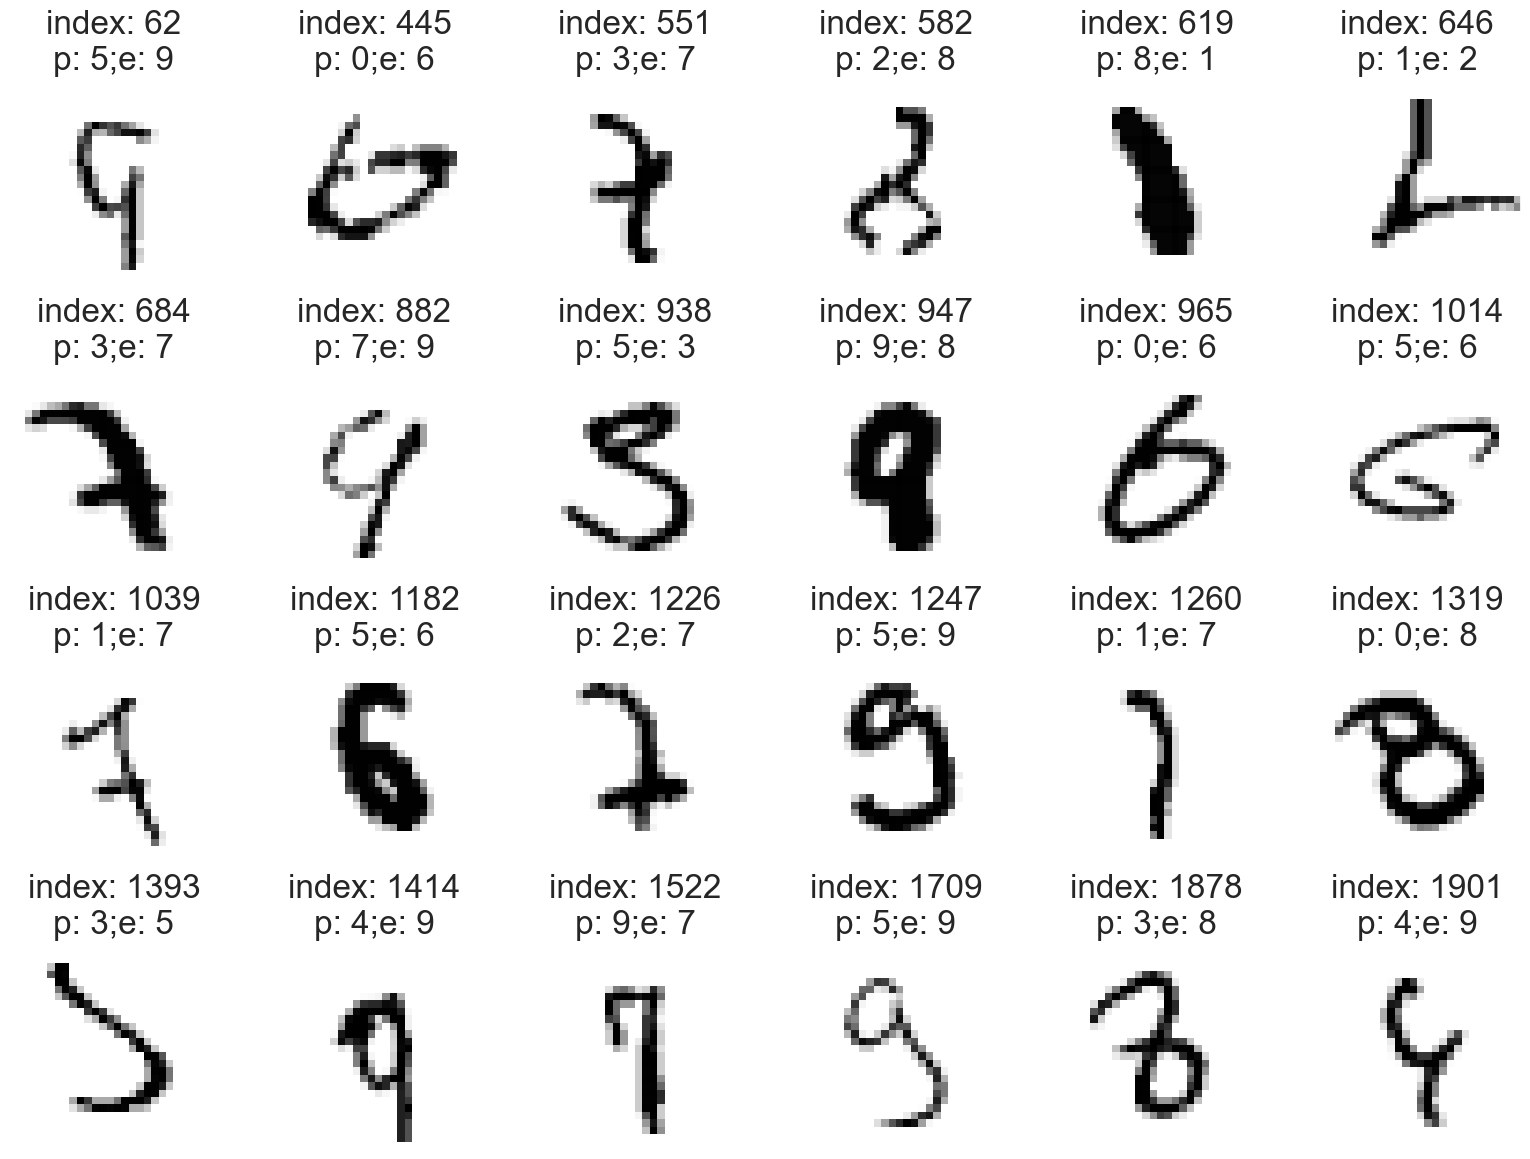

In [72]:
figure, axes = plt.subplots(nrows=4, ncols=6, figsize=(16,12))

for axes, item in zip(axes.ravel(), incorrect_predictions):
    index, image, predicted, expected = item
    axes.imshow(image, cmap=plt.cm.gray_r)
    axes.set_xticks([])
    axes.set_yticks([])
    axes.set_title(
        f'index: {index}\np: {predicted};e: {expected}'
    )
plt.tight_layout()

In [73]:
#Displaying the probabilities for several incorrect predictions

In [75]:
def display_probabilities(prediction):
    for index, probability in enumerate(prediction):
        print(f'{index}: {probability:.10%}')

In [76]:
display_probabilities(predictions[1878])

0: 0.0000132149%
1: 0.0000028963%
2: 0.0502099108%
3: 92.9039478302%
4: 0.0000000058%
5: 0.0000002224%
6: 0.0000163495%
7: 0.0000310823%
8: 7.0457622409%
9: 0.0000027846%


In [77]:
display_probabilities(predictions[1247])


0: 0.0726599479%
1: 0.0013933741%
2: 0.7513168268%
3: 0.3283224069%
4: 0.0000311865%
5: 96.3828921318%
6: 0.0000000304%
7: 0.0015943622%
8: 0.0054763757%
9: 2.4563023821%


In [78]:
#Saving and Loading a Model

In [80]:
cnn.save('mnist_cnn.h5')        #Stores the model's architecture and state information in a format called HDF5

In [83]:
from tensorflow.keras.models import load_model

In [84]:
cnn = load_model('mnist_cnn.h5')